# OLS Regression per K-Means Cluster

Loads the K-Means cluster artifacts from `cluster_outputs/` and fits a separate
**Ordinary Least Squares (OLS)** regression for each cluster on `log1p(copiesSold)`.

Reports per-cluster and combined:
- Train / Val / Test RMSE (log scale)
- R² (log scale)
- Full coefficient table with standard errors and t-statistics
- Top-coefficient bar charts, residual plots, predicted vs actual

**Prerequisite:** Run `kmean.ipynb` first.

In [1]:
import sys, os, warnings, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s  %(levelname)-8s  %(message)s', datefmt='%H:%M:%S')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
    print('statsmodels available — full coefficient tables enabled.')
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not found. Install with: pip install statsmodels --break-system-packages')
    print('Falling back to sklearn coefficients only.')

print('Libraries imported.')

statsmodels available — full coefficient tables enabled.
Libraries imported.


## 1. Load Artifacts from kmean.ipynb

In [2]:
ARTIFACTS = 'cluster_outputs'

required = ['X_features.npy', 'y_log.npy', 'cluster_labels.npy', 'feature_cols.json']
missing  = [f for f in required if not os.path.exists(f'{ARTIFACTS}/{f}')]
if missing:
    raise FileNotFoundError(
        f'Missing artifacts: {missing}\n'
        'Please run kmean.ipynb first.'
    )

X_full         = np.load(f'{ARTIFACTS}/X_features.npy')
y_log          = np.load(f'{ARTIFACTS}/y_log.npy')
cluster_labels = np.load(f'{ARTIFACTS}/cluster_labels.npy')

with open(f'{ARTIFACTS}/feature_cols.json') as f:
    feature_cols = json.load(f)

N_CLUSTERS = len(np.unique(cluster_labels))

print(f'X_full         : {X_full.shape}')
print(f'y_log          : {y_log.shape}   mean={y_log.mean():.3f}  std={y_log.std():.3f}')
print(f'N_CLUSTERS     : {N_CLUSTERS}')
print(f'feature_cols   : {len(feature_cols)} features')
print()
for i in range(N_CLUSTERS):
    n = (cluster_labels == i).sum()
    print(f'  Cluster {i}: {n:,} games  ({100*n/len(cluster_labels):.1f}%)')

X_full         : (80633, 60)
y_log          : (80633,)   mean=6.411  std=3.020
N_CLUSTERS     : 3
feature_cols   : 60 features

  Cluster 0: 7,618 games  (9.4%)
  Cluster 1: 38,243 games  (47.4%)
  Cluster 2: 34,772 games  (43.1%)


## 2. Train / Val / Test Splits per Cluster

In [3]:
splits = {}

for i in range(N_CLUSTERS):
    mask = cluster_labels == i
    X_c  = X_full[mask]
    y_c  = y_log[mask]

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_c, y_c, test_size=0.30, random_state=42)
    X_val, X_tst, y_val, y_tst = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

    splits[i] = {
        'X_train': X_tr,  'y_train': y_tr,
        'X_val':   X_val, 'y_val':   y_val,
        'X_test':  X_tst, 'y_test':  y_tst,
    }
    print(f'Cluster {i}  →  train={len(X_tr):,}  val={len(X_val):,}  test={len(X_tst):,}')

Cluster 0  →  train=5,332  val=1,143  test=1,143
Cluster 1  →  train=26,770  val=5,736  test=5,737
Cluster 2  →  train=24,340  val=5,216  test=5,216


## 3. Fit OLS per Cluster

In [4]:
ols_models  = {}
ols_results = []

for i in range(N_CLUSTERS):
    s = splits[i]
    print(f'\n{"="*55}')
    print(f'Cluster {i} — OLS')
    print(f'{"="*55}')

    lr = LinearRegression()
    lr.fit(s['X_train'], s['y_train'])
    ols_models[i] = lr

    y_tr_pred  = lr.predict(s['X_train'])
    y_val_pred = lr.predict(s['X_val'])
    y_tst_pred = lr.predict(s['X_test'])

    train_rmse = float(np.sqrt(mean_squared_error(s['y_train'], y_tr_pred)))
    val_rmse   = float(np.sqrt(mean_squared_error(s['y_val'],   y_val_pred)))
    test_rmse  = float(np.sqrt(mean_squared_error(s['y_test'],  y_tst_pred)))
    val_r2     = float(r2_score(s['y_val'],  y_val_pred))
    test_r2    = float(r2_score(s['y_test'], y_tst_pred))
    val_mae    = float(mean_absolute_error(s['y_val'],  y_val_pred))
    test_mae   = float(mean_absolute_error(s['y_test'], y_tst_pred))

    print(f'  Train RMSE_log : {train_rmse:.4f}')
    print(f'  Val   RMSE_log : {val_rmse:.4f}   Val  R² : {val_r2:.4f}')
    print(f'  Test  RMSE_log : {test_rmse:.4f}   Test R² : {test_r2:.4f}')

    ols_results.append({
        'Cluster':        i,
        'N_train':        len(s['X_train']),
        'Train_RMSE_log': round(train_rmse, 4),
        'Val_RMSE_log':   round(val_rmse,   4),
        'Test_RMSE_log':  round(test_rmse,  4),
        'Val_R2':         round(val_r2,     4),
        'Test_R2':        round(test_r2,    4),
        'Val_MAE_log':    round(val_mae,    4),
        'Test_MAE_log':   round(test_mae,   4),
    })

print('\n✓ All OLS models fitted.')


Cluster 0 — OLS
  Train RMSE_log : 1.8239
  Val   RMSE_log : 1.8298   Val  R² : 0.6206
  Test  RMSE_log : 1.9826   Test R² : 0.5910

Cluster 1 — OLS
  Train RMSE_log : 1.7190
  Val   RMSE_log : 1.7287   Val  R² : 0.6716
  Test  RMSE_log : 1.7111   Test R² : 0.6728

Cluster 2 — OLS
  Train RMSE_log : 1.9103
  Val   RMSE_log : 1.9243   Val  R² : 0.5598
  Test  RMSE_log : 1.9469   Test R² : 0.5478

✓ All OLS models fitted.


## 4. Summary Table + Combined Loss

In [5]:
ols_df = pd.DataFrame(ols_results).set_index('Cluster')

# Combined (pool all predictions)
all_val_true,  all_val_pred  = [], []
all_test_true, all_test_pred = [], []
all_tr_true,   all_tr_pred   = [], []

for i, m in ols_models.items():
    s = splits[i]
    all_tr_true.append(s['y_train']);    all_tr_pred.append(m.predict(s['X_train']))
    all_val_true.append(s['y_val']);     all_val_pred.append(m.predict(s['X_val']))
    all_test_true.append(s['y_test']);   all_test_pred.append(m.predict(s['X_test']))

cat = np.concatenate
combined_row = pd.DataFrame([{
    'Cluster':        'Combined',
    'N_train':        sum(len(s['X_train']) for s in splits.values()),
    'Train_RMSE_log': round(float(np.sqrt(mean_squared_error(cat(all_tr_true),   cat(all_tr_pred)))),   4),
    'Val_RMSE_log':   round(float(np.sqrt(mean_squared_error(cat(all_val_true),   cat(all_val_pred)))),  4),
    'Test_RMSE_log':  round(float(np.sqrt(mean_squared_error(cat(all_test_true),  cat(all_test_pred)))), 4),
    'Val_R2':         round(float(r2_score(cat(all_val_true),  cat(all_val_pred))),  4),
    'Test_R2':        round(float(r2_score(cat(all_test_true), cat(all_test_pred))), 4),
    'Val_MAE_log':    round(float(mean_absolute_error(cat(all_val_true),  cat(all_val_pred))),  4),
    'Test_MAE_log':   round(float(mean_absolute_error(cat(all_test_true), cat(all_test_pred))), 4),
}]).set_index('Cluster')

full_df = pd.concat([ols_df, combined_row])

print('OLS Per-Cluster and Combined Performance:')
display(full_df.style
    .background_gradient(cmap='RdYlGn_r', subset=['Train_RMSE_log', 'Val_RMSE_log', 'Test_RMSE_log'])
    .background_gradient(cmap='RdYlGn',   subset=['Val_R2', 'Test_R2'])
    .format('{:.4f}', subset=['Train_RMSE_log','Val_RMSE_log','Test_RMSE_log',
                               'Val_R2','Test_R2','Val_MAE_log','Test_MAE_log'])
    .format('{:,}', subset=['N_train'])
)

OLS Per-Cluster and Combined Performance:


,N_train,Train_RMSE_log,Val_RMSE_log,Test_RMSE_log,Val_R2,Test_R2,Val_MAE_log,Test_MAE_log
Cluster,,,,,,,,
0,"5,332",1.8239,1.8298,1.9826,0.6206,0.5910,1.4329,1.5705
1,"26,770",1.7190,1.7287,1.7111,0.6716,0.6728,1.3388,1.3341
2,"24,340",1.9103,1.9243,1.9469,0.5598,0.5478,1.5140,1.5334
Combined,"56,442",1.8137,1.8250,1.8425,0.6372,0.6288,1.4233,1.4424


## 5. Coefficient Tables

In [6]:
# Build coefficient DataFrame for each cluster
coef_dfs = {}

for i, m in ols_models.items():
    coef_df = pd.DataFrame({
        'feature':     feature_cols,
        'coefficient': m.coef_,
        'abs_coef':    np.abs(m.coef_),
    }).sort_values('abs_coef', ascending=False).reset_index(drop=True)
    coef_df['intercept'] = m.intercept_
    coef_dfs[i] = coef_df

    print(f'\n── Cluster {i} — Top 15 Coefficients (by |coef|) ──')
    display(coef_df[['feature', 'coefficient']].head(15).style
        .background_gradient(cmap='RdBu', subset=['coefficient'])
        .format({'coefficient': '{:.4f}'})
    )


── Cluster 0 — Top 15 Coefficients (by |coef|) ──


,feature,coefficient
0,publisher_class_ord,3.0740
1,is_free_to_play,2.2422
2,has_family_sharing,-2.0911
3,Linux,-1.9178
4,Mac,-1.7161
5,platform_count,1.2605
6,has_trading_cards,0.8900
7,tag_early_access,0.8377
8,has_workshop,0.6435
9,genre_simulation,0.5145



── Cluster 1 — Top 15 Coefficients (by |coef|) ──


,feature,coefficient
0,is_free_to_play,2.3701
1,publisher_class_ord,2.1594
2,has_trading_cards,1.5400
3,has_workshop,0.7673
4,Linux,-0.6818
5,tag_multiplayer,0.5706
6,has_family_sharing,-0.5321
7,tag_count,0.5179
8,has_dlc,0.4512
9,tag_3d,-0.4004



── Cluster 2 — Top 15 Coefficients (by |coef|) ──


,feature,coefficient
0,Linux,-2.4603
1,publisher_class_ord,2.4401
2,Mac,-2.1224
3,is_free_to_play,1.9758
4,has_trading_cards,1.7592
5,has_family_sharing,-1.6767
6,platform_count,1.5973
7,tag_horror,0.7649
8,has_dlc,0.7429
9,tag_colorful,-0.6398


## 6. Statsmodels OLS — Full Coefficient Table with p-values

In [7]:
if HAS_STATSMODELS:
    sm_models = {}
    for i in range(N_CLUSTERS):
        s = splits[i]
        X_sm = sm.add_constant(s['X_train'])
        sm_model = sm.OLS(s['y_train'], X_sm).fit()
        sm_models[i] = sm_model

        print(f'\n{"="*55}')
        print(f'Cluster {i} — Statsmodels OLS Summary')
        print(f'{"="*55}')
        print(f'R²={sm_model.rsquared:.4f}   Adj-R²={sm_model.rsquared_adj:.4f}   AIC={sm_model.aic:.1f}')

        # Top 15 significant features by |t-stat|
        coef_sm = pd.DataFrame({
            'feature':     ['intercept'] + feature_cols,
            'coef':        sm_model.params,
            'std_err':     sm_model.bse,
            't_stat':      sm_model.tvalues,
            'p_value':     sm_model.pvalues,
            'significant': sm_model.pvalues < 0.05,
        }).sort_values('t_stat', key=abs, ascending=False).reset_index(drop=True)

        display(coef_sm.head(15).style
            .background_gradient(cmap='RdBu',    subset=['coef'])
            .background_gradient(cmap='RdYlGn_r',subset=['p_value'])
            .format({'coef': '{:.4f}', 'std_err': '{:.4f}',
                     't_stat': '{:.3f}', 'p_value': '{:.4f}'})
            .applymap(lambda v: 'color: green; font-weight: bold' if v else '',
                      subset=['significant'])
        )
else:
    print('statsmodels not installed — skipping this cell.')
    print('Run:  pip install statsmodels --break-system-packages')


Cluster 0 — Statsmodels OLS Summary
R²=0.6233   Adj-R²=0.6190   AIC=21662.5


,feature,coef,std_err,t_stat,p_value,significant
0,publisher_class_ord,3.0740,0.0604,50.931,0.0000,True
1,intercept,5.9542,0.6529,9.119,0.0000,True
2,is_free_to_play,2.2422,0.3132,7.158,0.0000,True
3,has_family_sharing,-2.0911,0.2973,-7.032,0.0000,True
4,has_cloud_saves,0.4533,0.0693,6.546,0.0000,True
5,developer_freq,-0.4634,0.0713,-6.497,0.0000,True
6,Price,0.2872,0.0451,6.370,0.0000,True
7,language_count,0.3251,0.0530,6.134,0.0000,True
8,genre_simulation,0.5145,0.0845,6.086,0.0000,True
9,has_trading_cards,0.8900,0.1510,5.894,0.0000,True



Cluster 1 — Statsmodels OLS Summary
R²=0.6690   Adj-R²=0.6683   AIC=105094.4


,feature,coef,std_err,t_stat,p_value,significant
0,publisher_class_ord,2.1594,0.0210,103.051,0.0000,True
1,has_trading_cards,1.5400,0.0334,46.121,0.0000,True
2,Achievements,0.3958,0.0184,21.563,0.0000,True
3,tag_count,0.5179,0.0262,19.730,0.0000,True
4,developer_freq,-0.2526,0.0139,-18.150,0.0000,True
5,intercept,5.1924,0.3324,15.623,0.0000,True
6,is_free_to_play,2.3701,0.1627,14.566,0.0000,True
7,tag_3d,-0.4004,0.0296,-13.524,0.0000,True
8,language_count,0.1803,0.0139,12.932,0.0000,True
9,tag_multiplayer,0.5706,0.0454,12.560,0.0000,True



Cluster 2 — Statsmodels OLS Summary
R²=0.5670   Adj-R²=0.5659   AIC=100701.6


,feature,coef,std_err,t_stat,p_value,significant
0,publisher_class_ord,2.4401,0.0272,89.754,0.0000,True
1,has_trading_cards,1.7592,0.0635,27.695,0.0000,True
2,intercept,6.7426,0.3282,20.542,0.0000,True
3,Achievements,0.4288,0.0243,17.664,0.0000,True
4,developer_freq,-0.1816,0.0122,-14.901,0.0000,True
5,genre_simulation,0.5037,0.0374,13.469,0.0000,True
6,genre_casual,-0.3538,0.0314,-11.274,0.0000,True
7,tag_indie,0.4817,0.0436,11.059,0.0000,True
8,tag_count,0.4764,0.0456,10.442,0.0000,True
9,genre_action,-0.3498,0.0340,-10.290,0.0000,True


## 7. Plots

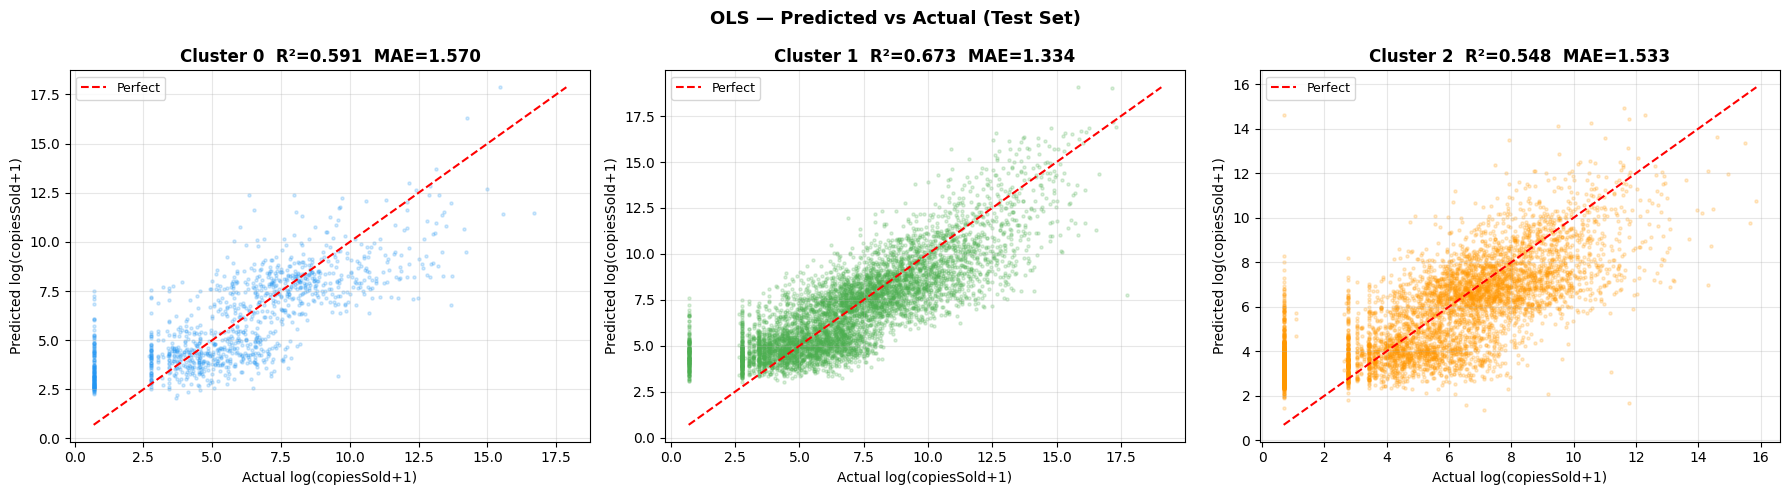

In [8]:
# ── Predicted vs Actual scatter — one panel per cluster ─────────────────────
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(6*N_CLUSTERS, 5))
if N_CLUSTERS == 1:
    axes = [axes]

for i, (m, ax) in enumerate(zip(ols_models.values(), axes)):
    s      = splits[i]
    y_pred = m.predict(s['X_test'])
    y_true = s['y_test']

    ax.scatter(y_true, y_pred, alpha=0.2, s=5, color=colors[i])
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f'Cluster {i}  R²={r2:.3f}  MAE={mae:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual log(copiesSold+1)')
    ax.set_ylabel('Predicted log(copiesSold+1)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('OLS — Predicted vs Actual (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

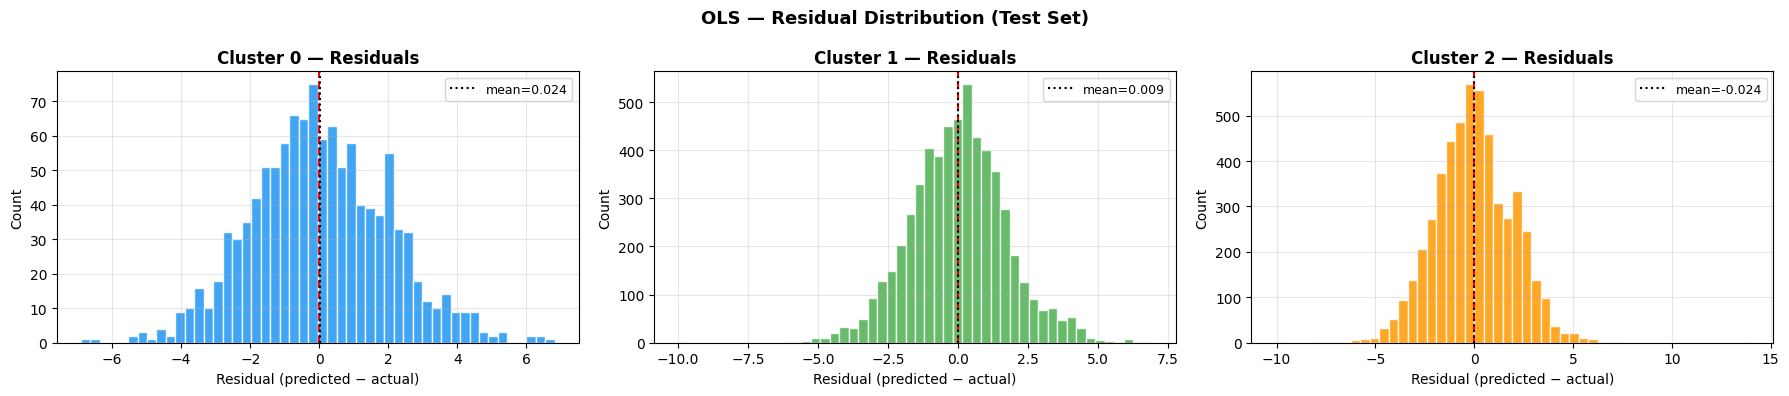

In [9]:
# ── Residual distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(6*N_CLUSTERS, 4))
if N_CLUSTERS == 1:
    axes = [axes]

for i, (m, ax) in enumerate(zip(ols_models.values(), axes)):
    s         = splits[i]
    residuals = m.predict(s['X_test']) - s['y_test']
    ax.hist(residuals, bins=50, color=colors[i], edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='black', linestyle=':', linewidth=1.5, label=f'mean={residuals.mean():.3f}')
    ax.set_title(f'Cluster {i} — Residuals', fontsize=12, fontweight='bold')
    ax.set_xlabel('Residual (predicted − actual)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('OLS — Residual Distribution (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

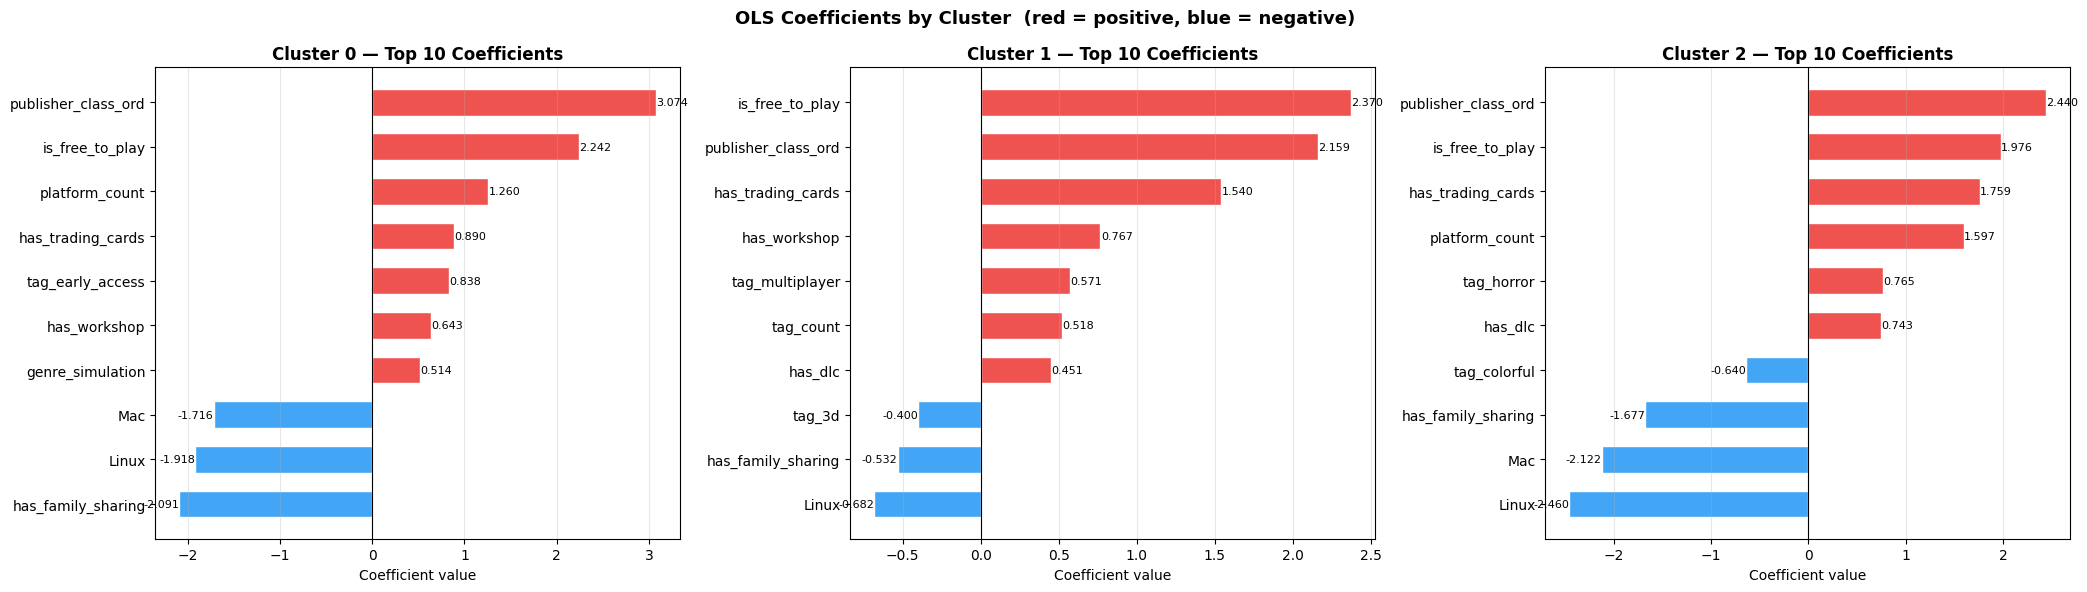

In [10]:
# ── Top 10 coefficients (by |coef|) per cluster — horizontal bar chart ───────
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(7*N_CLUSTERS, 6))
if N_CLUSTERS == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    top = coef_dfs[i].head(10).sort_values('coefficient')
    bar_colors = ['#EF5350' if v > 0 else '#42A5F5' for v in top['coefficient']]
    bars = ax.barh(top['feature'], top['coefficient'], color=bar_colors,
                   edgecolor='white', height=0.6)
    ax.axvline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, top['coefficient']):
        ha = 'left' if val >= 0 else 'right'
        offset = 0.002 if val >= 0 else -0.002
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha=ha, fontsize=8)
    ax.set_title(f'Cluster {i} — Top 10 Coefficients', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient value')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('OLS Coefficients by Cluster  (red = positive, blue = negative)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

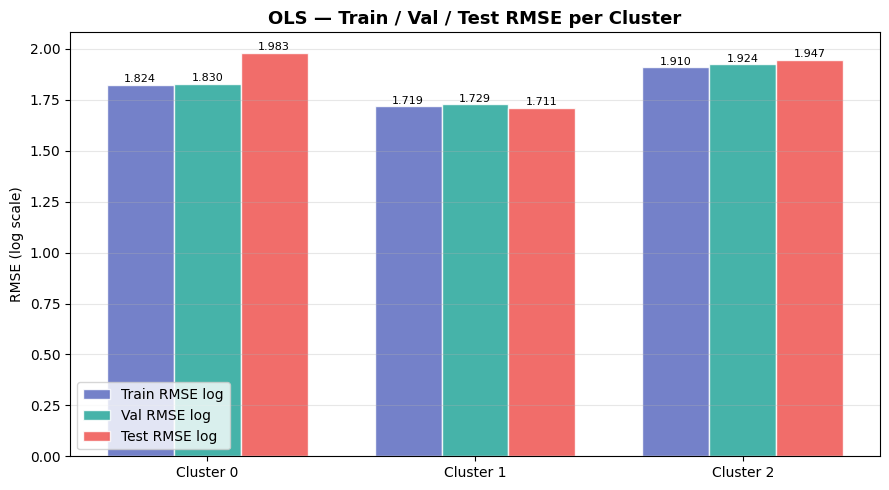


Combined (pooled) Test RMSE_log : 1.8425
Combined (pooled) Test R²       : 0.6288


In [11]:
# ── RMSE comparison bar chart ─────────────────────────────────────────────────
metrics_to_plot = ['Train_RMSE_log', 'Val_RMSE_log', 'Test_RMSE_log']
cluster_labels_str = [f'Cluster {i}' for i in range(N_CLUSTERS)]

x     = np.arange(N_CLUSTERS)
width = 0.25
metric_colors = ['#5C6BC0', '#26A69A', '#EF5350']

fig, ax = plt.subplots(figsize=(9, 5))
for j, (metric, color) in enumerate(zip(metrics_to_plot, metric_colors)):
    vals = [ols_df.loc[i, metric] for i in range(N_CLUSTERS)]
    bars = ax.bar(x + j*width, vals, width, label=metric.replace('_', ' '),
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(cluster_labels_str)
ax.set_ylabel('RMSE (log scale)')
ax.set_title('OLS — Train / Val / Test RMSE per Cluster', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print combined loss
print(f'\nCombined (pooled) Test RMSE_log : {full_df.loc["Combined", "Test_RMSE_log"]:.4f}')
print(f'Combined (pooled) Test R²       : {full_df.loc["Combined", "Test_R2"]:.4f}')

## 8. Coefficient Overlap Across Clusters

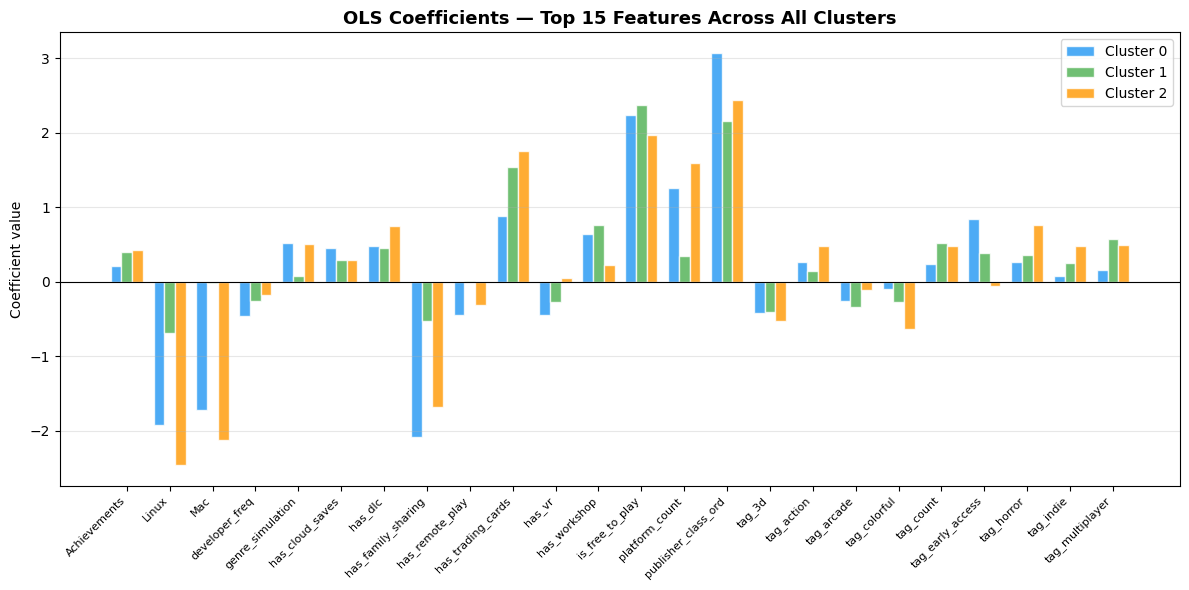

In [12]:
# Compare how the top features differ across clusters
top_n = 15
fig, ax = plt.subplots(figsize=(12, 6))

all_top = set()
for df in coef_dfs.values():
    all_top.update(df.head(top_n)['feature'].tolist())
all_top = sorted(all_top)

x     = np.arange(len(all_top))
width = 0.25

for j, (i, df) in enumerate(coef_dfs.items()):
    coef_map = dict(zip(df['feature'], df['coefficient']))
    vals = [coef_map.get(f, 0.0) for f in all_top]
    ax.bar(x + j*width, vals, width, label=f'Cluster {i}',
           color=colors[i], alpha=0.8, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(all_top, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Coefficient value')
ax.set_title(f'OLS Coefficients — Top {top_n} Features Across All Clusters',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Save Predictions

In [13]:
os.makedirs(ARTIFACTS, exist_ok=True)

rows = []
for i, m in ols_models.items():
    s      = splits[i]
    y_pred = m.predict(s['X_test'])
    y_true = s['y_test']
    for j in range(len(y_true)):
        rows.append({
            'cluster':          i,
            'actual_log':       float(y_true[j]),
            'predicted_log':    float(y_pred[j]),
            'actual_copies':    float(np.expm1(y_true[j])),
            'predicted_copies': float(np.expm1(y_pred[j])),
            'residual_log':     float(y_pred[j] - y_true[j]),
        })

pred_df = pd.DataFrame(rows)
pred_df.to_csv(f'{ARTIFACTS}/ols_kmeans_test_predictions.csv', index=False)
print(f'Saved → {ARTIFACTS}/ols_kmeans_test_predictions.csv  ({len(pred_df):,} rows)')
display(pred_df.head(6))

Saved → cluster_outputs/ols_kmeans_test_predictions.csv  (12,096 rows)


,cluster,actual_log,predicted_log,actual_copies,predicted_copies,residual_log
0,0,8.847216,7.188965,6953.997070,1323.731924,-1.658250
1,0,9.809232,10.302552,18199.998047,29807.600800,0.493320
2,0,7.214504,8.065481,1357.999756,3181.687880,0.850977
3,0,3.555348,4.864824,34.000004,128.648129,1.309476
4,0,3.433987,7.660953,29.999998,2122.780508,4.226966
5,0,2.772589,4.236717,15.000000,68.180345,1.464128
